# Final Applicability Domain Development for Deployment

This notebook develops the final Applicability Domain (AD) framework for the deployed Hybrid Random Forest permeability prediction model.

The objective is to construct a reliable chemical space reference using the complete training dataset and generate a deployment-ready Applicability Domain threshold.

The resulting AD model will later be integrated into the prediction pipeline and web application to provide prediction confidence estimates.

## Import Required Libraries

The required libraries are imported for loading reference features, nearest-neighbor analysis, data visualization, and threshold calculation.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors

## Loading Reference Chemical Space

The saved hybrid feature matrix used during final model development is loaded.

This dataset represents the chemical space learned by the deployed Hybrid Random Forest model.

In [3]:
reference_features = joblib.load(
    "../Model_Development_and_Saving.ipynb/training_reference_features.pkl"
)

print(reference_features.shape)

(12290, 2054)


## Constructing the Nearest Neighbor Model

A nearest-neighbor model is constructed using the complete reference chemical space.

Two neighbors are requested so that self-matches can be excluded during distance calculations.

In [4]:
nn = NearestNeighbors(
    n_neighbors=2,
    metric='euclidean'
)

nn.fit(reference_features)

print("Nearest Neighbor model created.")

Nearest Neighbor model created.


## Calculating Real Nearest Neighbor Distances

For each molecule, the nearest neighbor distance is calculated.

The first neighbor corresponds to the molecule itself and is ignored.

The second neighbor represents the closest distinct molecule and provides a meaningful estimate of local chemical space density.

In [5]:
distances, indices = nn.kneighbors(
    reference_features
)

real_distances = distances[:, 1]

print("Minimum:", real_distances.min())

print("Maximum:", real_distances.max())

print("Mean:", real_distances.mean())

print("Std:", real_distances.std())

Minimum: 0.0
Maximum: 206.74408527539464
Mean: 7.486713556245996
Std: 5.122257051803367


## Calculating Final Applicability Domain Threshold

A statistical threshold is calculated using:

Threshold = Mean Distance + 3 × Standard Deviation

Molecules with nearest-neighbor distances below this threshold are considered inside the Applicability Domain.

In [6]:
ad_threshold = (
    np.mean(real_distances)
    +
    3 * np.std(real_distances)
)

print("Final AD Threshold:", ad_threshold)

Final AD Threshold: 22.853484711656098


## Visualizing Nearest Neighbor Distance Distribution

The distribution of nearest-neighbor distances is visualized to understand the density of the learned chemical space.

The red dashed line represents the Applicability Domain threshold.

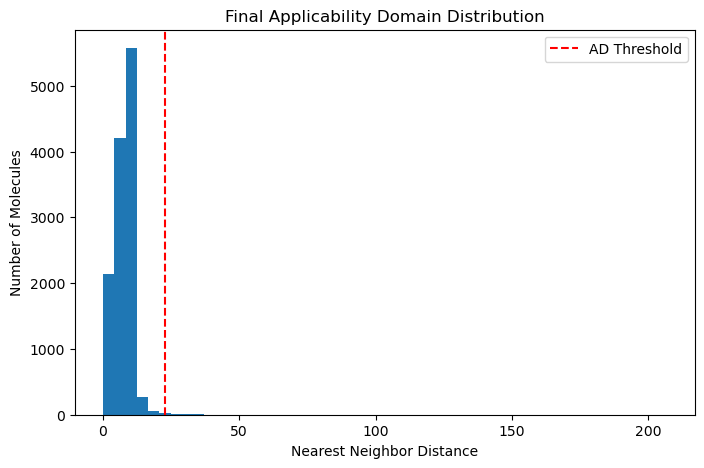

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    real_distances,
    bins=50
)

plt.axvline(
    ad_threshold,
    color='red',
    linestyle='--',
    label='AD Threshold'
)

plt.xlabel("Nearest Neighbor Distance")
plt.ylabel("Number of Molecules")

plt.title("Final Applicability Domain Distribution")

plt.legend()

plt.show()

In [9]:
joblib.dump(
    ad_threshold,
    "final_ad_threshold.pkl"
)

print("Final AD threshold saved.")

Final AD threshold saved.


# Final Applicability Domain Summary

A deployment-ready Applicability Domain (AD) was developed using the complete Hybrid feature space containing 12,290 molecules.

Nearest-neighbor analysis was performed using the second nearest neighbor to avoid self-matches and obtain meaningful chemical-space distances.

The final Applicability Domain threshold was calculated using:

Threshold = Mean Distance + 3 × Standard Deviation

Final AD Threshold: 22.8535

This threshold will be integrated into the prediction pipeline and deployed application to assess prediction reliability and confidence.

Molecules with nearest-neighbor distances below the threshold are considered inside the Applicability Domain and are expected to produce more reliable predictions.